<figure>
<center>
<img src="https://www.economicas.uba.ar/wp-content/uploads/2020/08/cropped-logo_FCE.png"/>
</center></figure>

# **Universidad de Buenos Aires**
## **Facultad de Ciencias Económicas**
### **Métodos Predictivos**
### Cátedra: Bianco
#### **Ejercicios de Inferencia Estadística — Resueltos**

In [1]:
import math
from scipy import stats
import numpy as np
from statsmodels.stats.weightstats import DescrStatsW
from statsmodels.stats.weightstats import ztest
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import norm
import matplotlib.pyplot as plt

1. Una empresa de bebidas quiere estimar el volumen promedio real servido por una llenadora automática. Toma una muestra de 64 botellas y obtiene una media muestral $\bar{x} = 52{,}0$ ml. El desvío poblacional del proceso es conocido y vale $\sigma = 8{,}0$ ml. ¿Cuál es el intervalo de confianza del 95% para la media poblacional $\mu$?

In [2]:
# --- Datos de entrada ---
n = 64
media_muestral = 52.0
sigma = 8.0
confianza = 0.95

# --- Cálculo del Error Estándar ---
error_estandar = sigma / np.sqrt(n)

# --- Construcción del Intervalo de Confianza (Z) ---
# Usamos stats.norm.interval porque conocemos el desvío poblacional (sigma)
limite_inf, limite_sup = stats.norm.interval(confianza, loc=media_muestral, scale=error_estandar)

# --- Respuesta Final ---
print(f"Respuesta: El intervalo de confianza del {confianza*100}% para la media poblacional es [{limite_inf:.2f} ml - {limite_sup:.2f} ml].")

Respuesta: El intervalo de confianza del 95.0% para la media poblacional es [50.04 ml - 53.96 ml].


2. Un contact center quiere estimar el tiempo promedio de atención. Se mide una muestra de 100 llamadas: $\bar{x} = 120{,}0$ segundos. Se sabe que $\sigma = 15{,}0$ segundos. ¿Cuál es el intervalo de confianza del 90% para $\mu$?

In [3]:
# --- Ingreso de parámetros del problema ---
media_muestral = 120.0
sigma = 15.0
n = 100
confianza = 0.90

# --- Cálculo del Error Estándar ---
# Es la desviación estándar de la distribución de la media
error_estandar = sigma / np.sqrt(n)

# --- Construcción del Intervalo ---
# Usamos stats.norm.interval porque conocemos el desvío poblacional (sigma)
# 'loc' es el centro (media) y 'scale' es la dispersión de la media (error estándar)
limite_inf, limite_sup = stats.norm.interval(confianza, loc=media_muestral, scale=error_estandar)

# --- PASO 4: Respuesta final ---
print(f"RESPUESTA: El intervalo de confianza del {confianza*100}% para el tiempo promedio de atención (μ) es [{limite_inf:.2f} s - {limite_sup:.2f} s].")

RESPUESTA: El intervalo de confianza del 90.0% para el tiempo promedio de atención (μ) es [117.53 s - 122.47 s].


3. Una planta de alimentos controla el peso neto promedio de los envases. Se auditan 49 unidades: $\bar{x} = 205{,}0$ g. Se conoce $\sigma = 14{,}0$ g.

Hipótesis: $H_0: \mu = 200{,}0$ g. Nivel de significancia 5% (dos colas). ¿Cuál es el estadístico $z_{obs}$ y la decisión?

In [4]:
# --- Datos del problema ---
media_muestral = 205.0
media_hipotesis = 200.0
sigma = 14.0
n = 49
alfa = 0.05

# --- Cálculo del Error Estándar ---
error_estandar = sigma / np.sqrt(n)

# --- Cálculo del Estadístico Z observado ---
# Representa a cuántas desviaciones estándar está nuestra media de la hipótesis
z_obs = (media_muestral - media_hipotesis) / error_estandar

# --- P-valor bilateral ---
p_valor = 2 * (1 - stats.norm.cdf(abs(z_obs)))

# --- Lógica de decisión ---
decision = "Rechazar H0" if p_valor < alfa else "No rechazar H0"

# --- Respuesta Final ---
print(f"RESULTADO: Z-observado = {z_obs:.2f} | P-valor = {p_valor:.4f}")
print(f"DECISIÓN: Con un nivel de significancia del {alfa*100}%, la decisión es: {decision}. Hay evidencia estadística suficiente, con un nivel de significancia del 5%, para concluir que el peso neto promedio de los envases es diferente de 200 g.")

RESULTADO: Z-observado = 2.50 | P-valor = 0.0124
DECISIÓN: Con un nivel de significancia del 5.0%, la decisión es: Rechazar H0. Hay evidencia estadística suficiente, con un nivel de significancia del 5%, para concluir que el peso neto promedio de los envases es diferente de 200 g.


4. Una empresa química mide el pH de un lote. Toma una muestra de 16 mediciones: media muestral $= 8{,}2$ y desvío muestral $s = 1{,}6$. ¿Cuál es el intervalo de confianza del 95% para $\mu$?

In [5]:
# --- Definición de parámetros muestrales ---
n = 16
media_muestral = 8.2
desvio_muestral = 1.6
confianza = 0.95
df = n - 1  # Fundamental para la distribución T de Student

# --- Cálculo del Error Estándar ---
# Usamos el desvío de la muestra 's'
error_estandar = desvio_muestral / np.sqrt(n)

# --- Construcción del Intervalo con Distribución T ---
# loc: media | scale: error estándar | df: grados de libertad
limite_inf, limite_sup = stats.t.interval(confianza, df=df, loc=media_muestral, scale=error_estandar)

# --- Respuesta final ---
print(f"RESULTADO: El intervalo de confianza del {confianza*100}% (T-dist) es [{limite_inf:.2f} - {limite_sup:.2f}]")

RESULTADO: El intervalo de confianza del 95.0% (T-dist) es [7.35 - 9.05]


5. Una empresa de logística quiere conocer con mayor precisión cuánto tarda en promedio una entrega en una de sus rutas más importantes. Para esto, analizaron 25 envíos recientes y encontraron que el tiempo promedio fue de 72 minutos, con una variabilidad (desvío) de 10 minutos.

Con esta información, quieren calcular un rango (o intervalo) donde estén seguros de que se encuentra el verdadero tiempo promedio de entrega, con un nivel de confianza del 99%.

In [6]:
# --- Datos obtenidos del relevamiento ---
n = 25
media_muestral = 72.0
desvio_muestral = 10.0
confianza = 0.99
grados_libertad = n - 1

# --- Cálculo del Error Estándar ---
error_estandar = desvio_muestral / np.sqrt(n)

# --- Cálculo del Intervalo de Confianza ---
# Usamos stats.t ya que el desvío es muestral y n es pequeño
limite_inf, limite_sup = stats.t.interval(confianza,
                                          df=grados_libertad,
                                          loc=media_muestral,
                                          scale=error_estandar)

# --- Resultado ---
print(f"ANÁLISIS DE LOGÍSTICA:")
print(f"Con un {confianza*100}% de confianza, el tiempo promedio real de entrega")
print(f"se estima entre {limite_inf:.2f} minutos y {limite_sup:.2f} minutos.")

ANÁLISIS DE LOGÍSTICA:
Con un 99.0% de confianza, el tiempo promedio real de entrega
se estima entre 66.41 minutos y 77.59 minutos.


6. Una fintech está evaluando el tiempo de respuesta de su API. Su objetivo es que el tiempo promedio sea de 5 segundos. Para comprobarlo, tomaron 12 mediciones y obtuvieron un promedio de 5.4 segundos, con una desviación estándar de 0.9 segundos. Quieren determinar si hay evidencia suficiente para afirmar que el tiempo promedio es **mayor** a 5 segundos, asumiendo un nivel de significancia del 10%.

¿Cuál es el valor del estadístico de prueba calculado y qué decisión tomarían?

In [7]:
# --- Definición de parámetros muestrales ---
n = 12
media_muestral = 5.4
media_hipotesis = 5.0
desvio_muestral = 0.9
alfa = 0.10
df = n - 1  # Grados de libertad para T de Student

# --- Cálculo del Estadístico de Prueba (t-obs) ---
error_estandar = desvio_muestral / np.sqrt(n)
t_obs = (media_muestral - media_hipotesis) / error_estandar

# --- Obtención de Valor Crítico y P-valor ---
t_critico = stats.t.ppf(1 - alfa, df)  # Valor de corte para el 10%
p_valor = 1 - stats.t.cdf(t_obs, df)  # Probabilidad cola derecha

# --- Decisión lógica ---
decision = "Rechazar H0" if t_obs > t_critico else "No rechazar H0"

# --- Respuesta final ---
print(f"RESULTADO: t-observado = {t_obs:.3f} | t-crítico = {t_critico:.3f} | p-valor = {p_valor:.4f}")
print(f"DECISIÓN: Con un nivel de significancia del {alfa*100}%, la decisión es: {decision}.")

RESULTADO: t-observado = 1.540 | t-crítico = 1.363 | p-valor = 0.0760
DECISIÓN: Con un nivel de significancia del 10.0%, la decisión es: Rechazar H0.


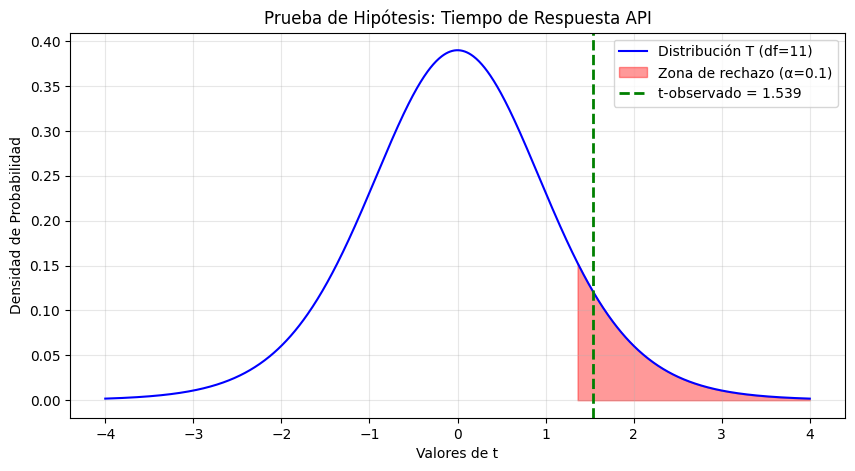

GRÁFICO GENERADO: Se observa que la línea verde (t-obs) cae dentro de la zona roja (rechazo).


In [8]:
# --- Configuración de los datos del ejercicio anterior ---
df = 11            # Grados de libertad (n-1)
t_obs = 1.539      # El valor que calculamos
t_crit = 1.363     # El límite de la tabla para alfa = 0.10

# --- Generación de la curva de distribución T ---
x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, df)

plt.figure(figsize=(10, 5))
plt.plot(x, y, label='Distribución T (df=11)', color='blue')

# --- Sombreado de la Zona de Rechazo (Alfa = 0.10) ---
x_rechazo = np.linspace(t_crit, 4, 100)
plt.fill_between(x_rechazo, stats.t.pdf(x_rechazo, df), color='red', alpha=0.4, label=f'Zona de rechazo (α={alfa})')

# --- Marcador para nuestro estadístico observado ---
plt.axvline(t_obs, color='green', linestyle='--', linewidth=2, label=f't-observado = {t_obs}')

# --- Estética del gráfico ---
plt.title('Prueba de Hipótesis: Tiempo de Respuesta API')
plt.xlabel('Valores de t')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("GRÁFICO GENERADO: Se observa que la línea verde (t-obs) cae dentro de la zona roja (rechazo).")

7. Una empresa de telecomunicaciones quiere conocer cuánto gastan en promedio sus clientes por mes. El objetivo es que el error máximo en la estimación sea de solo 2 unidades monetarias. Basándose en datos históricos, saben que la variabilidad (desviación estándar) del gasto es de 12 unidades. Para sentirse seguros de su cálculo, exigen un nivel de confianza del 95%.

¿Cuál es la cantidad mínima de clientes que deben incluir en su muestra para cumplir con estos requisitos?

In [9]:
# --- Definición de parámetros del problema ---
sigma = 12.0
error_maximo = 2.0
confianza = 0.95

# --- Cálculo del Valor Crítico Z ---
# Calculamos Z para el 95% (bilateral)
z = stats.norm.ppf(1 - (1 - confianza) / 2)

# --- Cálculo del Tamaño de Muestra (n) ---
n_exacto = (z * sigma / error_maximo)**2
n_final = int(np.ceil(n_exacto))  # Redondeo hacia arriba

# --- Respuesta final ---
print(f"RESULTADO: La muestra mínima requerida es de {n_final} clientes.")
print(f"Detalles técnicos: Z = {z:.3f}, n calculado = {n_exacto:.4f}")

RESULTADO: La muestra mínima requerida es de 139 clientes.
Detalles técnicos: Z = 1.960, n calculado = 138.2925


8. Una cadena de tiendas (retail) quiere estimar cuánto gasta en promedio cada cliente por compra (ticket promedio). Por experiencias anteriores, saben que la variabilidad histórica de ese gasto (desvío estándar) es de 9 unidades monetarias. Quieren que el intervalo de confianza total tenga una amplitud de 6 unidades (error de 3 unidades por lado), con un nivel de confianza del 90%.

¿Cuál es el tamaño mínimo de muestra necesario?

In [10]:
import numpy as np
from scipy import stats

# --- Definición de parámetros del requisito ---
sigma = 9.0
confianza = 0.90
amplitud_deseada = 6.0
margen_error = amplitud_deseada / 2

# --- Cálculo del Valor Crítico Z ---
# Obtenemos el valor Z para el 90% de confianza
z = stats.norm.ppf(1 - (1 - confianza) / 2)

# --- Cálculo del Tamaño de Muestra (n) ---
n_exacto = (z * sigma / margen_error)**2
n_final = int(np.ceil(n_exacto))  # Redondeo hacia arriba al entero superior

# --- Respuesta final ---
print(f"RESULTADO: El tamaño de muestra necesario es de {n_final} clientes.")
print(f"Cálculo técnico: n exacto = {n_exacto:.4f}, Z = {z:.3f}")

RESULTADO: El tamaño de muestra necesario es de 25 clientes.
Cálculo técnico: n exacto = 24.3499, Z = 1.645


9. Una empresa de transporte realizó una prueba piloto para medir el tiempo que se tarda en cargar los vehículos. En esa prueba, encontraron que la variabilidad (desvío) entre una carga y otra fue de 18 minutos.

Ahora quieren hacer un estudio más formal para estimar el tiempo promedio real de carga, con 95% de confianza y con un error máximo de 5 minutos.

¿Cuál es la cantidad mínima de operaciones de carga que deben medir para cumplir con estos requisitos?

In [11]:
# --- Definición de parámetros muestrales ---
sigma = 18.0
error_maximo = 5.0
confianza = 0.95

# --- Cálculo del Valor Crítico Z ---
# Obtenemos Z para el 95% de confianza (bilateral)
z = stats.norm.ppf(1 - (1 - confianza) / 2)

# --- Cálculo del Tamaño de Muestra (n) ---
n_exacto = (z * sigma / error_maximo)**2
n_final = int(np.ceil(n_exacto))  # Redondeo hacia arriba

# --- Respuesta final ---
print(f"RESULTADO: La muestra mínima requerida es de {n_final} operaciones de carga.")
print(f"Cálculo técnico: Z = {z:.3f} | n exacto = {n_exacto:.4f}")

RESULTADO: La muestra mínima requerida es de 50 operaciones de carga.
Cálculo técnico: Z = 1.960 | n exacto = 49.7853


10. Una empresa de energía quiere estimar el tiempo promedio que tardan en resolver los reclamos de sus clientes. Hicieron una prueba piloto y encontraron que el desvío estándar muestral ($s$) fue de 20,0 días. Ahora necesitan hacer un estudio más formal, con un 99% de confianza y con una amplitud total del intervalo de confianza de 10,0 unidades (error máximo de $\pm5{,}0$ unidades).

¿Cuál es la cantidad mínima de reclamos que deben analizar para cumplir con estos requisitos?

In [12]:
# --- Definición de parámetros del problema ---
sigma = 20.0
margen_error = 5.0  # La mitad de la amplitud total (10.0 / 2)
confianza = 0.99

# --- Cálculo del Valor Crítico Z ---
# Obtenemos Z para el 99% de confianza
z = stats.norm.ppf(1 - (1 - confianza) / 2)

# --- Cálculo del Tamaño de Muestra (n) ---
n_exacto = (z * sigma / margen_error)**2
n_final = int(np.ceil(n_exacto))  # Redondeo hacia arriba

# --- Respuesta final ---
print(f"RESULTADO: La muestra mínima requerida es de {n_final} reclamos.")
print(f"Detalle técnico: Z = {z:.3f} | n exacto = {n_exacto:.4f}")

RESULTADO: La muestra mínima requerida es de 107 reclamos.
Detalle técnico: Z = 2.576 | n exacto = 106.1583


Ahora entendí el problema que mencionaban el otro día. Cuando debemos encontrar $n$, debemos recurrir a la normal, porque en grandes cantidades la $T$ y $Z$ se van a ir pareciendo. En general se recurre a esto en la práctica.

Algunos plantean hacer un proceso iterativo una y otra vez con $T$ y los gl del primer ensayo, hasta que la $T$ se estabiliza en un valor. Pero lo otro es un error aceptable.

11. Una empresa manufacturera produce piezas mecánicas de precisión. Para evaluar este control de calidad, el equipo de ingeniería tomó una muestra aleatoria de 20 piezas de la línea de producción. Tras las mediciones, calcularon una varianza muestral ($s^2$) de 25,0. La gerencia técnica necesita conocer, con un 95% de confianza, entre qué valores oscila la verdadera varianza poblacional ($\sigma^2$) del proceso para decidir si deben calibrar las máquinas.

In [13]:
# --- Definición de parámetros del proceso ---
n = 20
varianza_muestral = 25.0
confianza = 0.95
df = n - 1  # Grados de libertad

# --- Obtención de valores críticos Chi-cuadrado ---
# Buscamos los puntos de corte para dejar 2.5% en cada cola
chi2_inf = stats.chi2.ppf((1 - confianza) / 2, df)  # Cola izquierda
chi2_sup = stats.chi2.ppf((1 + confianza) / 2, df)  # Cola derecha

# --- Cálculo de los límites del intervalo ---
# La fórmula invierte los valores de chi2 para los límites inf y sup
limite_inf = (df * varianza_muestral) / chi2_sup
limite_sup = (df * varianza_muestral) / chi2_inf

# --- Respuesta final ---
print(f"ANÁLISIS DE VARIABILIDAD:")
print(f"El intervalo de confianza del {confianza*100}% para la varianza poblacional (sigma^2)")
print(f"es de {limite_inf:.2f} a {limite_sup:.2f}.")

ANÁLISIS DE VARIABILIDAD:
El intervalo de confianza del 95.0% para la varianza poblacional (sigma^2)
es de 14.46 a 53.33.


12. Una planta embotelladora opera bajo la premisa de que la varianza ideal de su proceso de llenado es de 25,0. Recientemente, el equipo de mantenimiento sospecha que el desgaste de las válvulas ha alterado esta variabilidad. Para comprobarlo, se extrae una muestra de 15 envases y se mide su contenido, obteniendo una varianza muestral ($s^2$) de 36,0. El gerente de calidad necesita decidir, con un nivel de significancia del 5%, si hay evidencia estadística suficiente para afirmar que la varianza ha **cambiado** respecto al valor histórico.

In [14]:
# --- Definición de parámetros muestrales ---
n = 15
s2 = 36.0
sigma2_h0 = 25.0
alfa = 0.05
df = n - 1

# --- Cálculo del Estadístico Chi-cuadrado observado ---
chi2_obs = (df * s2) / sigma2_h0

# --- Obtención de Valores Críticos (Dos colas) ---
chi2_crit_inf = stats.chi2.ppf(alfa / 2, df)
chi2_crit_sup = stats.chi2.ppf(1 - alfa / 2, df)

# --- Lógica de decisión ---
rechazar = chi2_obs < chi2_crit_inf or chi2_obs > chi2_crit_sup
decision = "Rechazar H0" if rechazar else "No rechazar H0"

# --- Respuesta final ---
print(f"RESULTADO: chi2_obs = {chi2_obs:.2f}")
print(f"VALORES CRÍTICOS: Límite inf = {chi2_crit_inf:.3f} | Límite sup = {chi2_crit_sup:.3f}")
print(f"DECISIÓN: {decision}")

RESULTADO: chi2_obs = 20.16
VALORES CRÍTICOS: Límite inf = 5.629 | Límite sup = 26.119
DECISIÓN: No rechazar H0


13. El equipo de Marketing de una tienda online está analizando la efectividad de sus campañas de retención. Seleccionaron una muestra aleatoria de 400 clientes que realizaron su primera compra hace exactamente dos meses. Al revisar el historial de transacciones, detectaron que 92 de esos clientes volvieron a comprar dentro de los primeros 30 días.

La gerencia necesita un intervalo de confianza del 95% para la verdadera proporción de clientes que recompran en toda la base de datos.

In [15]:
# --- Definición de parámetros muestrales ---
n = 400
exitos = 92
confianza = 0.95

# --- Cálculo del Intervalo para Proporciones (Método Normal) ---
# Usamos alpha = 1 - confianza (0.05 para un 95%)
limite_inf, limite_sup = proportion_confint(count=exitos,
                                            nobs=n,
                                            alpha=(1 - confianza),
                                            method='normal')

# --- Respuesta final ---
print(f"ANÁLISIS DE FIDELIZACIÓN:")
print(f"En una muestra de {n} clientes, la tasa de recompra es del {(exitos/n):.1%}.")
print(f"El intervalo de confianza del {confianza*100}% para la proporción real")
print(f"es de {limite_inf:.4f} a {limite_sup:.4f} (aprox. {limite_inf:.1%} - {limite_sup:.1%}).")

ANÁLISIS DE FIDELIZACIÓN:
En una muestra de 400 clientes, la tasa de recompra es del 23.0%.
El intervalo de confianza del 95.0% para la proporción real
es de 0.1888 a 0.2712 (aprox. 18.9% - 27.1%).


14. El equipo de Producto de una software factory ha lanzado una nueva herramienta de automatización dentro de su plataforma. De los 150 usuarios que completaron la encuesta, 39 calificaron la función como "útil". El Product Manager necesita presentar un informe indicando, con un 90% de confianza, cuál es el rango real de aceptación de esta funcionalidad en toda su base de usuarios.

In [16]:
import numpy as np
from statsmodels.stats.proportion import proportion_confint

# --- Definición de parámetros muestrales ---
n = 150
exitos = 39
confianza = 0.90

# --- Cálculo del Intervalo para Proporciones ---
# El método 'normal' aplica la aproximación de Wald
limite_inf, limite_sup = proportion_confint(count=exitos,
                                            nobs=n,
                                            alpha=(1 - confianza),
                                            method='normal')

# --- Respuesta final ---
print(f"ANÁLISIS DE ADOPCIÓN DE SOFTWARE:")
print(f"En la muestra, la utilidad percibida es del {(exitos/n):.1%}.")
print(f"El intervalo de confianza del {confianza*100}% es [{limite_inf:.4f} - {limite_sup:.4f}]")
print(f"Es decir, entre el {limite_inf:.2%} y el {limite_sup:.2%}.")

ANÁLISIS DE ADOPCIÓN DE SOFTWARE:
En la muestra, la utilidad percibida es del 26.0%.
El intervalo de confianza del 90.0% es [0.2011 - 0.3189]
Es decir, entre el 20.11% y el 31.89%.


15. El departamento de Control de Calidad de una fábrica de microchips tiene un estándar estricto: la tasa de unidades defectuosas no debe superar el 25%. Se inspeccionan 200 unidades al azar y se encuentran 62 piezas defectuosas. El supervisor necesita determinar, con un nivel de significancia del 5%, si hay evidencia estadística suficiente para afirmar que la tasa de defectos ha **superado** el límite permitido.

In [17]:
# --- Definición de parámetros del problema ---
count = 62
nobs = 200
p_hipotesis = 0.25
alfa = 0.05

# --- Cálculo del Estadístico Z y el P-valor ---
# 'larger' indica que probamos si la proporción es MAYOR (cola derecha)
z_obs, p_valor = proportions_ztest(count=count,
                                   nobs=nobs,
                                   value=p_hipotesis,
                                   alternative='larger')

# --- Lógica de decisión ---
decision = "Rechazar H0" if p_valor < alfa else "No rechazar H0"

# --- Respuesta final ---
print(f"RESULTADO: z-observado = {z_obs:.2f} | p-valor = {p_valor:.4f}")
print(f"DECISIÓN: {decision} (Tasa de defectos fuera de control)")

RESULTADO: z-observado = 1.83 | p-valor = 0.0333
DECISIÓN: Rechazar H0 (Tasa de defectos fuera de control)


16. Una empresa de telecomunicaciones quiere estimar la proporción de clientes que cambiarían de proveedor si se les ofreciera un mejor precio. Estudios previos sugieren que esta proporción ronda el 40%. Quieren un error máximo del 5% con un nivel de confianza del 95%.

¿Cuántos clientes deben encuestar?

In [18]:
# --- Definición de parámetros del estudio ---
p_esperado = 0.40
q_esperado = 1 - p_esperado
error_maximo = 0.05
confianza = 0.95

# --- Cálculo del Valor Crítico Z ---
z = stats.norm.ppf(1 - (1 - confianza) / 2)

# --- Cálculo del Tamaño de Muestra (n) ---
n_exacto = (z**2 * p_esperado * q_esperado) / (error_maximo**2)
n_final = int(np.ceil(n_exacto))  # Redondeo hacia arriba

# --- Respuesta final ---
print(f"ESTUDIO DE TELECOMUNICACIONES:")
print(f"Para un error de {error_maximo*100}% y confianza del {confianza*100}%,")
print(f"se requieren entrevistar a {n_final} clientes.")
print(f"Cálculo técnico: n = {n_exacto:.4f}")

ESTUDIO DE TELECOMUNICACIONES:
Para un error de 5.0% y confianza del 95.0%,
se requieren entrevistar a 369 clientes.
Cálculo técnico: n = 368.7800


17. Un banco digital quiere estimar la proporción de usuarios que utilizan su aplicación móvil al menos una vez por semana. No tienen información previa sobre esta proporción, por lo que utilizarán el caso más conservador ($p = 0{,}5$). Necesitan un error máximo del 3% con un nivel de confianza del 99%.

¿Cuántos usuarios deben encuestar?

In [19]:
# --- Definición de parámetros (Caso Conservador) ---
p_conservador = 0.50
q_conservador = 1 - p_conservador
error_maximo = 0.03
confianza = 0.99

# --- Cálculo del Valor Crítico Z ---
# Para 99% de confianza, z es aproximadamente 2.576
z = stats.norm.ppf(1 - (1 - confianza) / 2)

# --- Cálculo del Tamaño de Muestra (n) ---
n_exacto = (z**2 * p_conservador * q_conservador) / (error_maximo**2)
n_final = int(np.ceil(n_exacto))  # Redondeo al entero superior

# --- Respuesta final ---
print(f"ESTUDIO DE BANCA DIGITAL:")
print(f"Bajo el caso más conservador (p=0.5), con confianza del {confianza*100}%")
print(f"y un error del {error_maximo*100}%, la muestra mínima es: {n_final} usuarios.")
print(f"Valor crítico Z utilizado: {z:.3f}")

ESTUDIO DE BANCA DIGITAL:
Bajo el caso más conservador (p=0.5), con confianza del 99.0%
y un error del 3.0%, la muestra mínima es: 1844 usuarios.
Valor crítico Z utilizado: 2.576


18. El departamento de Compras de una empresa industrial está auditando a sus dos principales proveedores de materia prima. Se busca estimar, con un 95% de confianza, cuál es la verdadera diferencia entre el tiempo promedio de entrega de A y el de B ($\mu_A - \mu_B$).

- Proveedor A: $n = 50$, $\bar{x} = 10{,}5$ días, $\sigma_A = 1{,}2$ días.
- Proveedor B: $m = 60$, $\bar{y} = 9{,}8$ días, $\sigma_B = 1{,}5$ días.
- Nivel de confianza: $95\%$ ($\alpha = 0{,}05 \rightarrow z_{\alpha/2} = 1{,}96$).

In [20]:
# --- Parámetros Proveedor A ---
n = 50
media_a = 10.5
sigma_a = 1.2

# --- Parámetros Proveedor B ---
m = 60
media_b = 9.8
sigma_b = 1.5

confianza = 0.95

# --- Cálculo de la Diferencia y Error Estándar ---
dif_medias = media_a - media_b
error_estandar_dif = np.sqrt((sigma_a**2 / n) + (sigma_b**2 / m))

# --- Valor Crítico Z ---
z_critico = stats.norm.ppf(1 - (1 - confianza) / 2)

# --- Límites del Intervalo ---
margen_error = z_critico * error_estandar_dif
limite_inf = dif_medias - margen_error
limite_sup = dif_medias + margen_error

# --- Respuesta final ---
print(f"ANÁLISIS COMPARATIVO DE PROVEEDORES:")
print(f"Diferencia puntual: {dif_medias:.2f} días a favor del Proveedor B.")
print(f"Intervalo de confianza ({confianza*100}%): [{limite_inf:.3f} - {limite_sup:.3f}]")

ANÁLISIS COMPARATIVO DE PROVEEDORES:
Diferencia puntual: 0.70 días a favor del Proveedor B.
Intervalo de confianza (95.0%): [0.195 - 1.205]


19. El departamento de Recursos Humanos ha implementado un nuevo programa de formación técnica. Para medir su impacto, comparan los puntajes finales de dos equipos diferentes. Se busca estimar, con un 95% de confianza, cuál es la verdadera diferencia de puntajes promedio ($\mu_X - \mu_Y$) entre ambos equipos.

- Equipo X: $n = 18$, $\bar{x} = 102$, $s_x = 8$.
- Equipo Y: $m = 22$, $\bar{y} = 97$, $s_y = 10$.
- Nivel de confianza: $95\%$ ($\alpha = 0{,}05$).
- Grados de libertad ($df$): $n + m - 2 = 18 + 22 - 2 = 38$.

In [21]:
import numpy as np
from scipy import stats

# --- Datos Equipo X ---
n = 18
media_x = 102
s_x = 8

# --- Datos Equipo Y ---
m = 22
media_y = 97
s_y = 10

confianza = 0.95
df = n + m - 2

# --- Cálculo de Varianza Combinada (Pooled Variance) ---
s2_p = ((n - 1) * s_x**2 + (m - 1) * s_y**2) / df

# --- Error Estándar de la Diferencia ---
se_diff = np.sqrt(s2_p * (1/n + 1/m))

# --- Valor Crítico T ---
t_crit = stats.t.ppf(1 - (1 - confianza) / 2, df)

# --- Intervalo de Confianza ---
margen_error = t_crit * se_diff
dif_muestral = media_x - media_y
lim_inf, lim_sup = dif_muestral - margen_error, dif_muestral + margen_error

print(f"ANÁLISIS DE CAPACITACIÓN RRHH:")
print(f"Diferencia de medias: {dif_muestral}")
print(f"Varianza combinada (s2_p): {s2_p:.2f}")
print(f"Intervalo 95% T: [{lim_inf:.2f} , {lim_sup:.2f}]")

ANÁLISIS DE CAPACITACIÓN RRHH:
Diferencia de medias: 5
Varianza combinada (s2_p): 83.89
Intervalo 95% T: [-0.89 , 10.89]


20. El equipo de Growth Marketing ha lanzado dos versiones de una página de aterrizaje para una nueva campaña de suscripción. Tras una semana de tráfico, la Página A tuvo 78 conversiones sobre 300 visitas, mientras que la Página B logró 50 sobre 250. Marketing necesita saber, con un 95% de confianza, cuál es el rango de la diferencia de rendimiento entre ambas ($\pi_A - \pi_B$).

- Página A: $n = 300$, $x = 78$ $\Rightarrow \hat{p}_A = 78/300 = 0{,}26$.
- Página B: $m = 250$, $y = 50$ $\Rightarrow \hat{p}_B = 50/250 = 0{,}20$.
- Diferencia observada: $0{,}26 - 0{,}20 = 0{,}06$ (6 puntos porcentuales).
- Nivel de confianza: $95\%$ ($\alpha = 0{,}05 \rightarrow z_{\alpha/2} = 1{,}96$).

In [22]:
# Verifica varianza combinada del ejercicio anterior
s2_p

83.89473684210526

In [23]:
# --- Datos Página A ---
nA = 300
xA = 78

# --- Datos Página B ---
nB = 250
xB = 50

confianza = 0.95

pA = xA / nA
pB = xB / nB

# --- Diferencia observada ---
diff = pA - pB

# --- Error Estándar ---
SE = np.sqrt((pA*(1-pA)/nA) + (pB*(1-pB)/nB))

# --- Valor Crítico ---
alpha = 1 - confianza
z = norm.ppf(1 - alpha/2)

# --- Margen de error ---
ME = z * SE

# Intervalo de confianza
LI = diff - ME
LS = diff + ME

# --- Resultados ---
print("Proporción A:", round(pA, 3))
print("Proporción B:", round(pB, 3))
print("Diferencia observada:", round(diff, 3))
print("Error estándar:", round(SE, 4))
print("Valor crítico Z:", round(z, 2))

print("\nIntervalo de confianza 95%:")
print("LI =", round(LI, 3))
print("LS =", round(LS, 3))

Proporción A: 0.26
Proporción B: 0.2
Diferencia observada: 0.06
Error estándar: 0.0358
Valor crítico Z: 1.96

Intervalo de confianza 95%:
LI = -0.01
LS = 0.13
